# Extract Affine Medoid from GUMMarker XML

Compute the medoid frame from a range of affine matrices in a Localite GUMMarkers XML file, write medoid-only output XML, and generate QC plots.

Based on `extract_affine_medoid.py` with spatial summary visualization from `find_medoid_updated.py`.

**Index inputs** refer to the `index` attribute on `<Element index="...">`, not the position in the discovered element list.

## Parameters

In [159]:
from pathlib import Path

# --- User inputs ---
INPUT_XML = Path("/Users/suhas/Desktop/temp/online/sub-01_GUMMarkers20260504.xml")
START_INDEX = 920        
END_INDEX = 1037           
OUTPUT_FOLDER = Path("/Users/suhas/Desktop/temp/online")
OUTPUT_XML_FILENAME = "sub-01_prot-4_con_medoid.xml"
DESCRIPTION_LABEL = "online_prot-4_con"

# Optional: XPath to limit which elements are scanned for affine matrices.
POSITION_XPATH = "//Element[@type='InstrumentMarker']"
MATRIX_ORDER = "row-major"  # or "column-major"

OUTPUT_XML = OUTPUT_FOLDER / OUTPUT_XML_FILENAME

## Helper functions (from `extract_affine_medoid.py`)

In [160]:
%matplotlib inline

import csv
import math
import re

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from lxml import etree

try:
    import seaborn as sns
    sns.set_theme(style="white", context="notebook", font="Arial")
except ImportError:
    pass
plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "Helvetica", "DejaVu Sans"],
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.edgecolor": "black",
    "axes.linewidth": 0.8,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": False,
    "legend.frameon": False,
})

FLOAT_RE = re.compile(
    r"[-+]?(?:\d*\.\d+|\d+\.?)(?:[eE][-+]?\d+)?"
)


def parse_16_floats(text):
    values = [float(x) for x in FLOAT_RE.findall(text or "")]
    if len(values) == 16:
        return values
    return None


def matrix4d_attrib_to_text(element):
    """Parse Localite Matrix4D data00..data33 attributes into 16 floats."""
    for child in element.iterdescendants():
        tag = etree.QName(child).localname
        if tag != "Matrix4D":
            continue
        comp = {k: float(v) for k, v in child.attrib.items() if k.startswith("data")}
        if len(comp) < 16:
            continue
        values = [comp.get(f"data{r}{c}", 0.0) for r in range(4) for c in range(4)]
        return " ".join(str(v) for v in values)
    return None


def find_matrix_text_in_element(element):
    likely_attr_names = [
        "matrix", "affine", "affinetransform", "transform",
        "transformation", "stageposition",
    ]

    for attr_name, attr_value in element.attrib.items():
        compact = attr_name.lower().replace("_", "").replace("-", "")
        if any(name in compact for name in likely_attr_names):
            values = parse_16_floats(attr_value)
            if values is not None:
                return attr_value

    if element.text:
        values = parse_16_floats(element.text)
        if values is not None:
            return element.text

    for child in element.iterdescendants():
        if child.text:
            values = parse_16_floats(child.text)
            if values is not None:
                return child.text

        for attr_name, attr_value in child.attrib.items():
            compact = attr_name.lower().replace("_", "").replace("-", "")
            if any(name in compact for name in likely_attr_names):
                values = parse_16_floats(attr_value)
                if values is not None:
                    return attr_value

    return matrix4d_attrib_to_text(element)


def matrix_from_text(text, matrix_order):
    values = parse_16_floats(text)
    if values is None:
        raise ValueError("Expected exactly 16 numeric values for affine matrix.")
    arr = np.array(values, dtype=float)
    if matrix_order == "row-major":
        return arr.reshape((4, 4))
    if matrix_order == "column-major":
        return arr.reshape((4, 4), order="F")
    raise ValueError("matrix_order must be 'row-major' or 'column-major'.")


def extract_translation_and_rotation(matrix):
    rotation = matrix[:3, :3]
    translation = matrix[:3, 3]
    return translation, rotation


def discover_position_elements(root, position_xpath=None):
    if position_xpath:
        candidates = root.xpath(position_xpath)
    else:
        candidates = list(root.iter())
    found = []
    for element in candidates:
        if find_matrix_text_in_element(element) is not None:
            found.append(element)
    return found


def element_frame_index(element):
    idx = element.get("index")
    return int(idx) if idx is not None else None


def select_elements_by_frame_range(position_elements, start_frame, end_frame):
    """Keep elements whose <Element index="..."> is in [start_frame, end_frame]."""
    selected = [
        element for element in position_elements
        if (frame := element_frame_index(element)) is not None
        and start_frame <= frame <= end_frame
    ]
    if not selected:
        raise ValueError(
            f"No elements found with <Element index> in [{start_frame}, {end_frame}]."
        )
    selected.sort(key=element_frame_index)
    return selected


def compute_medoid_index(points):
    points = np.asarray(points, dtype=float)
    if len(points) == 0:
        raise ValueError("No points provided.")
    diff = points[:, None, :] - points[None, :, :]
    distances = np.linalg.norm(diff, axis=2)
    total_distances = distances.sum(axis=1)
    return int(np.argmin(total_distances)), total_distances


def project_to_rotation_matrix(R):
    U, _, Vt = np.linalg.svd(R)
    R_clean = U @ Vt
    if np.linalg.det(R_clean) < 0:
        U[:, -1] *= -1
        R_clean = U @ Vt
    return R_clean


def rotation_matrix_to_euler_xyz_degrees(R):
    R = project_to_rotation_matrix(R)
    sy = math.sqrt(R[0, 0] ** 2 + R[1, 0] ** 2)
    singular = sy < 1e-8
    if not singular:
        x = math.atan2(R[2, 1], R[2, 2])
        y = math.atan2(-R[2, 0], sy)
        z = math.atan2(R[1, 0], R[0, 0])
    else:
        x = math.atan2(-R[1, 2], R[1, 1])
        y = math.atan2(-R[2, 0], sy)
        z = 0.0
    return np.degrees([x, y, z])


def relative_rotations_degrees(rotations):
    R0 = project_to_rotation_matrix(rotations[0])
    R0_inv = R0.T
    rel_eulers = []
    for R in rotations:
        R_clean = project_to_rotation_matrix(R)
        R_rel = R0_inv @ R_clean
        rel_eulers.append(rotation_matrix_to_euler_xyz_degrees(R_rel))
    return np.array(rel_eulers, dtype=float)


def plot_unit_vector(relative_translations, medoid_local_index):
    vectors = np.asarray(relative_translations, dtype=float)
    norms = np.linalg.norm(vectors, axis=1)
    unit_vectors = np.zeros_like(vectors)
    nonzero = norms > 1e-12
    unit_vectors[nonzero] = vectors[nonzero] / norms[nonzero, None]

    fig = plt.figure()
    ax = fig.add_subplot(111, projection="3d")
    for i, v in enumerate(unit_vectors):
        if i == medoid_local_index:
            continue
        ax.quiver(0, 0, 0, v[0], v[1], v[2], color="blue", length=1.0, normalize=False, alpha=0.6)
    mv = unit_vectors[medoid_local_index]
    ax.quiver(0, 0, 0, mv[0], mv[1], mv[2], color="red", length=1.0, normalize=False, linewidth=2.5)
    ax.scatter([mv[0]], [mv[1]], [mv[2]], color="red", s=60)
    ax.set_title("Unit translation vectors; medoid in red")
    ax.set_xlabel("X")
    ax.set_ylabel("Y")
    ax.set_zlabel("Z")
    ax.set_xlim([-1, 1])
    ax.set_ylim([-1, 1])
    ax.set_zlim([-1, 1])
    plt.tight_layout()
    plt.show()


def plot_xyz_line(values, frame_indices, medoid_frame, title, ylabel):
    values = np.asarray(values, dtype=float)
    frame_indices = np.asarray(frame_indices, dtype=int)
    medoid_plot_idx = int(np.where(frame_indices == medoid_frame)[0][0])

    fig = plt.figure()
    plt.plot(frame_indices, values[:, 0], label="X")
    plt.plot(frame_indices, values[:, 1], label="Y")
    plt.plot(frame_indices, values[:, 2], label="Z")
    plt.axvline(medoid_frame, color="red", linestyle="--", label="Medoid")
    plt.scatter([medoid_frame], [values[medoid_plot_idx, 0]], color="red", marker="o")
    plt.title(title)
    plt.xlabel("Element index")
    plt.ylabel(ylabel)
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


def write_summary_csv(output_file, relative_translations, relative_rotations,
                      medoid_local_index, medoid_frame):
    columns = {
        "translation_x": relative_translations[:, 0],
        "translation_y": relative_translations[:, 1],
        "translation_z": relative_translations[:, 2],
        "rotation_x_deg": relative_rotations[:, 0],
        "rotation_y_deg": relative_rotations[:, 1],
        "rotation_z_deg": relative_rotations[:, 2],
    }
    with open(output_file, "w", newline="", encoding="utf-8") as f:
        writer = csv.writer(f)
        writer.writerow([
            "metric", "count", "mean", "std", "min", "median", "max",
            "medoid_value", "medoid_local_index", "medoid_frame",
        ])
        for metric, values in columns.items():
            values = np.asarray(values, dtype=float)
            writer.writerow([
                metric, len(values), float(np.mean(values)),
                float(np.std(values, ddof=1)) if len(values) > 1 else 0.0,
                float(np.min(values)), float(np.median(values)), float(np.max(values)),
                float(values[medoid_local_index]), medoid_local_index, medoid_frame,
            ])


def write_medoid_xml(original_tree, medoid_element, label, output_xml_file):
    """Write a medoid-only XML with a single <Element index="0">."""
    medoid_element.set("index", "0")
    medoid_element.set("medoid", "true")
    medoid_element.set("label", label)
    medoid_element.set("description", label)

    for child in medoid_element.iterdescendants():
        tag = etree.QName(child).localname
        if tag == "InstrumentMarker":
            child.set("description", label)

    root = original_tree.getroot()
    for child in list(root):
        if not isinstance(child.tag, str):
            continue
        if etree.QName(child).localname == "Element" and child is not medoid_element:
            root.remove(child)

    original_tree.write(
        str(output_xml_file), encoding="utf-8",
        xml_declaration=True, pretty_print=True,
    )

## Run medoid extraction

In [161]:
if not INPUT_XML.exists():
    raise FileNotFoundError(f"Input XML file does not exist: {INPUT_XML}")
if START_INDEX < 0:
    raise ValueError("START_INDEX must be >= 0.")
if END_INDEX < START_INDEX:
    raise ValueError("END_INDEX must be >= START_INDEX.")

OUTPUT_FOLDER.mkdir(parents=True, exist_ok=True)

parser_config = etree.XMLParser(
    remove_blank_text=False, remove_comments=False,
    remove_pis=False, recover=False,
)
tree = etree.parse(str(INPUT_XML), parser_config)
root = tree.getroot()

position_elements = discover_position_elements(root, position_xpath=POSITION_XPATH)
if not position_elements:
    raise ValueError(
        "No XML elements containing 4x4 affine matrices were found. "
        "Try changing POSITION_XPATH."
    )

available_frames = sorted(
    frame for el in position_elements if (frame := element_frame_index(el)) is not None
)
print(f"Total affine elements found: {len(position_elements)}")
print(f"Available Element indices: {available_frames[0]} to {available_frames[-1]}")

selected_elements = select_elements_by_frame_range(
    position_elements, START_INDEX, END_INDEX
)
frame_indices = [element_frame_index(el) for el in selected_elements]

matrices, translations, rotations = [], [], []
for element in selected_elements:
    matrix_text = find_matrix_text_in_element(element)
    if matrix_text is None:
        raise ValueError("Selected XML element does not contain a parseable 4x4 matrix.")
    matrix = matrix_from_text(matrix_text, MATRIX_ORDER)
    translation, rotation = extract_translation_and_rotation(matrix)
    matrices.append(matrix)
    translations.append(translation)
    rotations.append(rotation)

translations = np.array(translations, dtype=float)
rotations = np.array(rotations, dtype=float)

medoid_local_index, total_distances = compute_medoid_index(translations)
medoid_element = selected_elements[medoid_local_index]
medoid_frame = element_frame_index(medoid_element)

start_translation = translations[0]
relative_translations = translations - start_translation
relative_rotations = relative_rotations_degrees(rotations)

summary_csv = OUTPUT_FOLDER / "summary_stats.csv"

write_summary_csv(
    summary_csv, relative_translations, relative_rotations,
    medoid_local_index, medoid_frame,
)
write_medoid_xml(tree, medoid_element, DESCRIPTION_LABEL, OUTPUT_XML)

print("Done.")
print(f"Input XML: {INPUT_XML}")
print(f"Selected Element index range: {START_INDEX} to {END_INDEX}, inclusive ({len(selected_elements)} elements)")
print(f"Medoid local index (within selection): {medoid_local_index}")
print(f"Medoid Element index: {medoid_frame}")
print(f"Medoid translation XYZ: {translations[medoid_local_index].tolist()}")
print(f"Medoid total distance: {float(total_distances[medoid_local_index]):.4f}")
print()
print("Outputs:")
print(f"  XML: {OUTPUT_XML}")
print(f"  Summary CSV: {summary_csv}")

Total affine elements found: 1031
Available Element indices: 0 to 1038
Done.
Input XML: /Users/suhas/Desktop/temp/online/sub-01_GUMMarkers20260504.xml
Selected Element index range: 920 to 1037, inclusive (118 elements)
Medoid local index (within selection): 31
Medoid Element index: 951
Medoid translation XYZ: [66.10345238303455, 173.836846202218, 152.34618058739514]
Medoid total distance: 49.5094

Outputs:
  XML: /Users/suhas/Desktop/temp/online/sub-01_prot-4_con_medoid.xml
  Summary CSV: /Users/suhas/Desktop/temp/online/summary_stats.csv


## Analysis relative to starting position

Run the **Run medoid extraction** cell first.


In [162]:
from contextlib import contextmanager
from matplotlib.ticker import MaxNLocator
from mpl_toolkits.axes_grid1 import make_axes_locatable

try:
    import seaborn as sns
except ImportError:
    sns = None

AXIS_LIMIT_MM = 1.0
BIN_WIDTH_MM = 0.1
POINT_SIZE = 24
POINT_ALPHA = 0.65
MEDOID_SIZE = int(POINT_SIZE * 1.25)
LINE_WIDTH = 1.5
MEDOID_LINE_WIDTH = LINE_WIDTH * 1.25
REF_LINE_WIDTH = 0.5
REF_LEVELS = (-0.5, 0.0, 0.5)
REF_COLOR_MINOR = "#cccccc"
HIST_SIZE = "24%"
HIST_PAD = 0.38
HIST_LABEL_SIZE = 9
HIST_TICK_SIZE = 9
GENERAL_COLOR = "#c4c4c4"
MEDOID_COLOR = "black"
XYZ_COLORS = ["#66c2a5", "#fc8d62", "#8da0cb"]
XYZ_LABELS = ["X", "Y", "Z"]

pos_ids = np.arange(1, len(frame_indices) + 1)
start_translation = translations[0]
rel_trans_start = translations - start_translation
rel_rot_start = relative_rotations_degrees(rotations)


@contextmanager
def use_ggpubr_theme():
    """ggpubr theme_pubr-like styling for matplotlib."""
    if sns is not None:
        sns.set_theme(style="white", context="notebook", font="Arial")
    with plt.rc_context({
        "font.family": "sans-serif",
        "font.sans-serif": ["Arial", "Helvetica", "DejaVu Sans"],
        "figure.facecolor": "white",
        "axes.facecolor": "white",
        "axes.edgecolor": "black",
        "axes.linewidth": 0.8,
        "axes.labelsize": 11,
        "axes.titlesize": 12,
        "xtick.labelsize": 10,
        "ytick.labelsize": 10,
        "legend.fontsize": 9,
        "legend.frameon": False,
        "axes.grid": False,
    }):
        yield


def _ggpubr_open_ax(ax):
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.grid(False)


def _boxed_ax(ax):
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_linewidth(0.8)
    ax.grid(False)


def _set_square_limits(ax, limit_mm=AXIS_LIMIT_MM):
    ax.set_xlim(-limit_mm, limit_mm)
    ax.set_ylim(-limit_mm, limit_mm)
    ax.set_aspect("equal", adjustable="box")


def _ref_line_kwargs(color):
    return dict(color=color, linewidth=REF_LINE_WIDTH, linestyle=":", alpha=0.75, zorder=0)


def _add_y_ref_lines(ax, zero_color=REF_COLOR_MINOR):
    for level in REF_LEVELS:
        color = zero_color if level == 0.0 else REF_COLOR_MINOR
        ax.axhline(level, **_ref_line_kwargs(color))


def _add_xy_ref_lines(ax, x_zero_color, y_zero_color):
    for level in REF_LEVELS:
        ax.axhline(level, **_ref_line_kwargs(y_zero_color if level == 0.0 else REF_COLOR_MINOR))
        ax.axvline(level, **_ref_line_kwargs(x_zero_color if level == 0.0 else REF_COLOR_MINOR))


def mm_bin_edges(bin_width_mm, limit_mm=AXIS_LIMIT_MM):
    return np.arange(-limit_mm, limit_mm + bin_width_mm / 2, bin_width_mm)


def apply_mm_limits_3d(ax, limit_mm=AXIS_LIMIT_MM):
    ax.set_xlim(-limit_mm, limit_mm)
    ax.set_ylim(-limit_mm, limit_mm)
    ax.set_zlim(-limit_mm, limit_mm)
    ax.margins(0)


def _filled_scatter(ax, x, y, *, c, s, alpha=1.0, zorder=2):
    ax.scatter(x, y, c=c, s=s, alpha=alpha, linewidths=0, edgecolors="none", zorder=zorder)


def _style_projection_ax(ax, xlabel, ylabel, title, d0, d1):
    _set_square_limits(ax)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_title(title, pad=8)
    _boxed_ax(ax)
    _add_xy_ref_lines(ax, XYZ_COLORS[d0], XYZ_COLORS[d1])


def _style_hist_axis_only(ax, orientation="horizontal"):
    """Marginal histogram: single baseline axis with count ticks."""
    for spine in ax.spines.values():
        spine.set_visible(False)
    if orientation == "horizontal":
        ax.spines["left"].set_visible(True)
        ax.set_xlabel("Count", fontsize=HIST_LABEL_SIZE, labelpad=3)
        ax.tick_params(axis="x", labelsize=HIST_TICK_SIZE, length=3, pad=2)
        ax.tick_params(axis="y", labelleft=False, length=2, pad=1)
        ax.xaxis.set_major_locator(MaxNLocator(integer=True, nbins=4))
    else:
        ax.spines["bottom"].set_visible(True)
        ax.set_ylabel("Count", fontsize=HIST_LABEL_SIZE, labelpad=3)
        ax.tick_params(axis="x", labelbottom=False, length=2, pad=1)
        ax.tick_params(axis="y", labelsize=HIST_TICK_SIZE, length=3, pad=2)
        ax.yaxis.set_major_locator(MaxNLocator(integer=True, nbins=4))


def _add_marginal_histograms(ax, x, y, color_x, color_y):
    bins = mm_bin_edges(BIN_WIDTH_MM)
    divider = make_axes_locatable(ax)
    ax_histx = divider.append_axes("top", size=HIST_SIZE, pad=HIST_PAD, sharex=ax)
    ax_histy = divider.append_axes("right", size=HIST_SIZE, pad=HIST_PAD, sharey=ax)
    ax_histx.hist(x, bins=bins, color=color_x, alpha=0.8, edgecolor="none")
    ax_histy.hist(y, bins=bins, orientation="horizontal", color=color_y, alpha=0.8, edgecolor="none")
    ax_histx.set_xlim(-AXIS_LIMIT_MM, AXIS_LIMIT_MM)
    ax_histy.set_ylim(-AXIS_LIMIT_MM, AXIS_LIMIT_MM)
    _style_hist_axis_only(ax_histx, orientation="vertical")
    _style_hist_axis_only(ax_histy, orientation="horizontal")
    ax.set_aspect("equal", adjustable="box")


def _scatter_points_2d(ax, x, y, medoid_idx):
    mask = np.ones(len(x), dtype=bool)
    mask[medoid_idx] = False
    _filled_scatter(ax, x[mask], y[mask], c=GENERAL_COLOR, s=POINT_SIZE, alpha=POINT_ALPHA)
    _filled_scatter(ax, [x[medoid_idx]], [y[medoid_idx]], c=MEDOID_COLOR, s=MEDOID_SIZE, alpha=1.0, zorder=5)


def _boxplot_summary(ax, data_by_axis, axis_labels, colors, ylabel, title):
    bp = ax.boxplot(data_by_axis, labels=axis_labels, showfliers=False, patch_artist=True, widths=0.55)
    for patch, color in zip(bp["boxes"], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.35)
        patch.set_edgecolor(color)
    for med, color in zip(bp["medians"], colors):
        med.set_color(color)
        med.set_linewidth(1.5)
    means = [float(np.mean(d)) for d in data_by_axis]
    for i, (m, color) in enumerate(zip(means, colors)):
        ax.scatter(i + 1, m, marker="D", s=30, c=color, linewidths=0, edgecolors="none", zorder=5)
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    _add_y_ref_lines(ax)
    _ggpubr_open_ax(ax)


def plot_translation_rotation_lines(trans_values, rot_values, position_ids, medoid_idx):
    with use_ggpubr_theme():
        fig = plt.figure(figsize=(14, 7), facecolor="white")
        fig.suptitle("Transducer variation relative to starting position", fontsize=13, y=0.98)
        gs = gridspec.GridSpec(2, 2, figure=fig, width_ratios=[3, 1], hspace=0.35, wspace=0.25)
        panels = [
            (gs[0, 0], gs[0, 1], np.asarray(trans_values),
             "Δ position (mm)", "Translation vs position ID", "Translation summary", False),
            (gs[1, 0], gs[1, 1], np.asarray(rot_values),
             "Δ orientation (degree)", "Rotation vs position ID", "Rotation summary", True),
        ]
        for ax_line_spec, ax_box_spec, values, ylabel, line_title, box_title, show_xlabel in panels:
            ax_line = fig.add_subplot(ax_line_spec)
            ax_box = fig.add_subplot(ax_box_spec)
            for j, lab in enumerate(XYZ_LABELS):
                ax_line.plot(position_ids, values[:, j], label=lab,
                             color=XYZ_COLORS[j], linewidth=LINE_WIDTH)
            _add_y_ref_lines(ax_line)
            ax_line.axvline(position_ids[medoid_idx], color=MEDOID_COLOR,
                            linewidth=MEDOID_LINE_WIDTH, linestyle="--", alpha=1.0,
                            label="Medoid", zorder=4)
            ax_line.set_ylim(-AXIS_LIMIT_MM, AXIS_LIMIT_MM)
            ax_line.set_ylabel(ylabel)
            ax_line.set_title(line_title)
            _ggpubr_open_ax(ax_line)
            ax_line.legend(loc="best")
            _boxplot_summary(ax_box, [values[:, 0], values[:, 1], values[:, 2]],
                             ["ΔX", "ΔY", "ΔZ"], XYZ_COLORS, ylabel, box_title)
            ax_box.set_ylim(-AXIS_LIMIT_MM, AXIS_LIMIT_MM)
            if show_xlabel:
                ax_line.set_xlabel("Position ID")
        plt.show()


def plot_spatial_1x4(coords, medoid_idx):
    coords = np.asarray(coords, dtype=float)
    mask = np.ones(len(coords), dtype=bool)
    mask[medoid_idx] = False

    with use_ggpubr_theme():
        fig = plt.figure(figsize=(14, 9), facecolor="white")
        fig.suptitle("Transducer variation relative to starting position", fontsize=13, y=0.98)
        gs = gridspec.GridSpec(
            2, 3, figure=fig, height_ratios=[0.88, 1.12],
            hspace=0.35, wspace=0.25,
        )

        ax3d = fig.add_subplot(gs[0, :], projection="3d")
        ax3d.scatter(coords[mask, 0], coords[mask, 1], coords[mask, 2],
                     c=GENERAL_COLOR, s=POINT_SIZE, alpha=POINT_ALPHA, depthshade=False,
                     linewidths=0, edgecolors="none")
        ax3d.scatter(coords[medoid_idx, 0], coords[medoid_idx, 1], coords[medoid_idx, 2],
                     c=MEDOID_COLOR, s=MEDOID_SIZE, alpha=1.0, depthshade=False,
                     linewidths=0, edgecolors="none", zorder=10)
        ax3d.set_xlabel("ΔX (mm)", color=XYZ_COLORS[0], labelpad=4)
        ax3d.set_ylabel("ΔY (mm)", color=XYZ_COLORS[1], labelpad=4)
        ax3d.set_zlabel("ΔZ (mm)", color=XYZ_COLORS[2], labelpad=4)
        ax3d.set_title("3D translation scatter", pad=6)
        apply_mm_limits_3d(ax3d)
        try:
            ax3d.set_box_aspect((1, 1, 1), zoom=1.2)
        except TypeError:
            ax3d.set_box_aspect((1, 1, 1))
            ax3d.dist = 7
        ax3d.view_init(elev=22, azim=-58)
        for pane in (ax3d.xaxis.pane, ax3d.yaxis.pane, ax3d.zaxis.pane):
            pane.fill = False
            pane.set_edgecolor("#dddddd")
        ax3d.grid(False)

        projections = [
            (gs[1, 0], 0, 1, "ΔX (mm)", "ΔY (mm)", "XY projection"),
            (gs[1, 1], 0, 2, "ΔX (mm)", "ΔZ (mm)", "XZ projection"),
            (gs[1, 2], 1, 2, "ΔY (mm)", "ΔZ (mm)", "YZ projection"),
        ]
        for spec, d0, d1, xl, yl, title in projections:
            ax = fig.add_subplot(spec)
            _scatter_points_2d(ax, coords[:, d0], coords[:, d1], medoid_idx)
            _style_projection_ax(ax, xl, yl, title, d0, d1)
            _add_marginal_histograms(ax, coords[:, d0], coords[:, d1],
                                     XYZ_COLORS[d0], XYZ_COLORS[d1])

        plt.show()


print(f"Positions: {len(pos_ids)} | Medoid: pos {pos_ids[medoid_local_index]}")



Positions: 118 | Medoid: pos 32


### Translation & rotation vs position ID


/var/folders/69/tp2r466136g518b4m3fvhqpw0000gn/T/ipykernel_88754/2498069653.py:157: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_by_axis, labels=axis_labels, showfliers=False, patch_artist=True, widths=0.55)
/var/folders/69/tp2r466136g518b4m3fvhqpw0000gn/T/ipykernel_88754/2498069653.py:157: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_by_axis, labels=axis_labels, showfliers=False, patch_artist=True, widths=0.55)


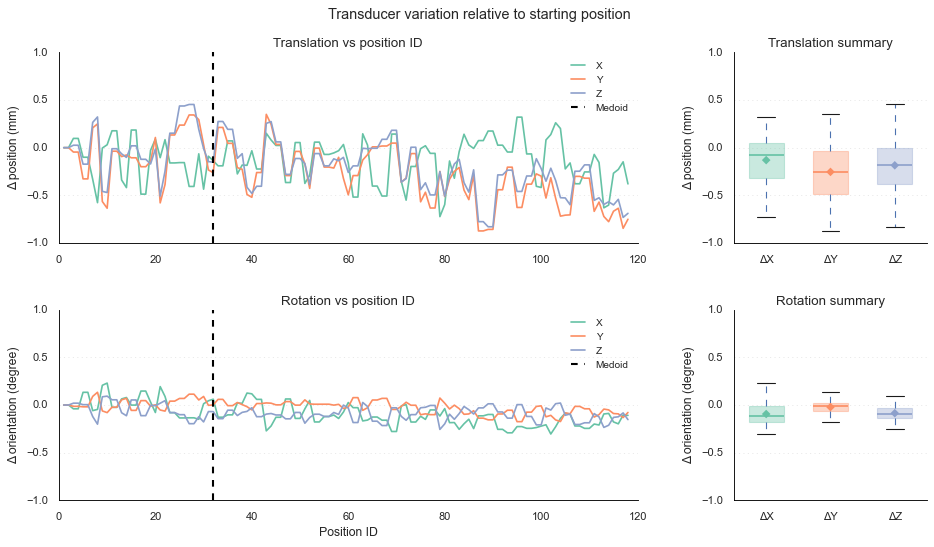

In [163]:
plot_translation_rotation_lines(
    rel_trans_start, rel_rot_start, pos_ids,
    medoid_idx=medoid_local_index,
)


### Spatial spread (3D top, projections bottom)


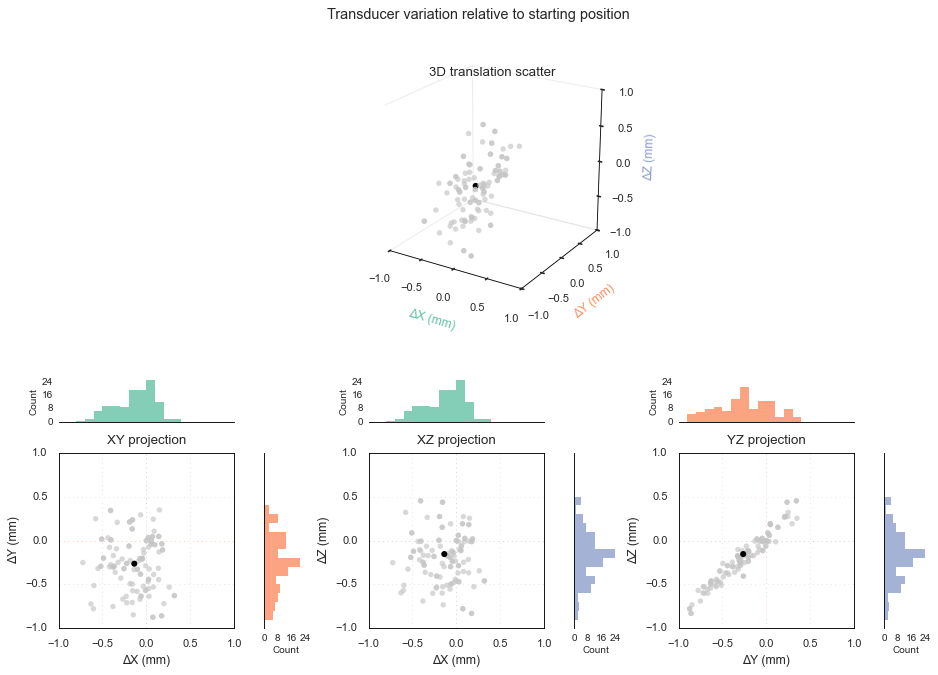

In [164]:
plot_spatial_1x4(rel_trans_start, medoid_idx=medoid_local_index)
